# Corpus EDA — Information Loss in Video Transcripts

**Research question.** Can a transcript-only Transformer identify low-contribution segments such that removing them causes minimal loss of factual/semantic content, and does this performance vary across length and genre?

**Hypotheses this EDA touches:**
- **H1** — longer videos contain proportionally more removable content. We characterize length distributions and look at length × redundancy proxies.
- **H3** — performance varies by genre. We compare per-genre filler density, lexical diversity, and repetition.
- **H4** — transcript-only model struggles with visual / pedagogical importance. We measure proxies (speech rate, visual-reference markers) that hint at how much content lives off-transcript.
- **H2** is not testable in EDA — it requires the model. But we set up the segment-level features that will feed weak labeling.

**Outputs:**
- Visualizations of corpus shape and per-genre features.
- `data/processed/corpus_summary.csv` — per-video summary (no raw transcript) used in later hypothesis tests.

**Caveat:** every per-video metric in this notebook is a **proxy**, not ground truth for "information loss" or "importance." Their job is to characterize the corpus and inform the weak labeling functions — the real evaluation happens later on the gold subset.

In [3]:
import json
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

# ── Consistent style ──────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# ── Shared genre palette & order (reused in every section) ───────────────────
GENRE_ORDER = ["commentary", "entertainment", "lectures", "podcasts", "ted", "tv_series"]
GENRE_PALETTE = {
    "commentary":   "#4C72B0",
    "entertainment":"#937860",
    "lectures":     "#DD8452",
    "podcasts":     "#55A868",
    "ted":          "#C44E52",
    "tv_series":    "#8172B3",
}

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

RAW_DIR       = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)


## 1. Load corpus

One row per video. The full transcript stays in memory only while we compute features — it is dropped before we save the summary frame.

In [4]:
def load_corpus(raw_dir: Path) -> pd.DataFrame:
    rows = []
    for path in sorted(raw_dir.rglob("*.json")):
        try:
            doc = json.loads(path.read_text(encoding="utf-8"))
        except Exception as e:
            print(f"  skip {path.name}: {e}")
            continue
        rows.append({
            "video_id": doc["video_id"],
            "genre": doc["genre"],
            "channel": doc.get("channel"),
            "title": doc.get("title"),
            "duration_sec": doc.get("duration"),
            "length_bucket": doc.get("length_bucket"),
            "caption_type": doc["caption_type"],
            "word_count": doc["word_count"],
            "n_segments": len(doc["transcript"]),
            "transcript": doc["transcript"],
        })
    return pd.DataFrame(rows)


df = load_corpus(RAW_DIR)
print(f"Loaded {len(df)} transcripts from {RAW_DIR.resolve()}")
if len(df) == 0:
    print("⚠  No data yet. Run `python src/scrape.py --sources sources.csv` first, then re-run this notebook.")
df.head()

Loaded 5000 transcripts from C:\Users\asus\OneDrive\Desktop\lang-tech\data\raw


,video_id,genre,channel,title,duration_sec,length_bucket,caption_type,word_count,n_segments,transcript
0,--CWTjd8rkY,commentary,Kurtis Conner,I Found a Super Weird Instructional Video from...,1582.0,long,auto,5314,771,[{'text': 'hey guys before the video starts ju...
1,--SXFB7m6mk,commentary,Folding Ideas,An American Tail: Fievel Goes to Video Game Hell,1326.0,long,manual,3690,327,[{'text': 'Don Bluth's 1986 animated film An A...
2,-4lc3CG9_gg,commentary,Jarvis Johnson,Wasting Food For Clout,1663.0,long,manual,5203,758,[{'text': '- [Newscaster] This video is sponso...
3,-75m4h4I-m8,commentary,Nicole Rafiee,chronically online girl explains Stranger Thin...,2616.0,long,auto,9500,1347,"[{'text': 'Will [screaming]', 'start': 0.24, '..."
4,-EzLk6BrzxQ,commentary,FunkyFrogBait,Let's Talk About BOOKTOK,2303.0,long,auto,6508,925,[{'text': 'my name is ambrosia Starlight and I...


## 2. Corpus overview & quality

**Sanity checks first.** Are quotas balanced? Do we have enough manual captions in each genre to compare against auto?

In [5]:
print("Per-genre counts:")
print(df["genre"].value_counts(), "\n")

print("Genre × length bucket:")
print(pd.crosstab(df["genre"], df["length_bucket"]), "\n")

print("Genre × caption type:")
print(pd.crosstab(df["genre"], df["caption_type"]))

Per-genre counts:
genre
lectures         1200
commentary        900
podcasts          900
entertainment     820
ted               700
tv_series         480
Name: count, dtype: int64 

Genre × length bucket:
length_bucket  long  medium  short
genre                             
commentary      615     280      5
entertainment   612     208      0
lectures        724     410     66
podcasts        881      19      0
ted             100     534     66
tv_series       405      69      6 

Genre × caption type:
caption_type   auto  manual
genre                      
commentary      471     429
entertainment   358     462
lectures        354     846
podcasts        584     316
ted             319     381
tv_series       271     209


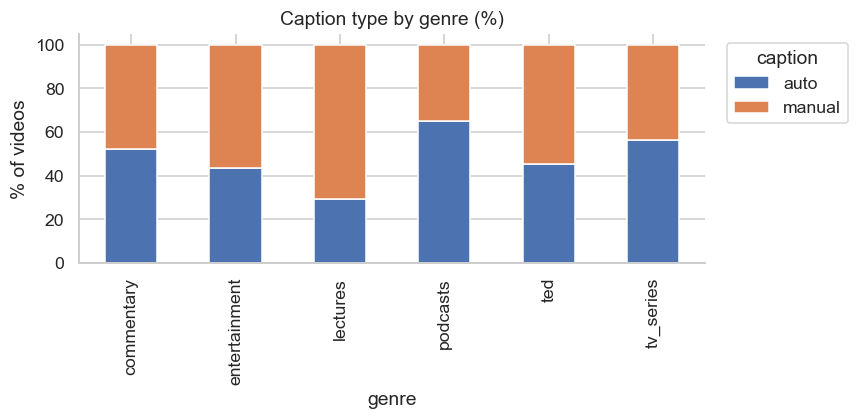

In [6]:
caption_pct = (
    df.groupby("genre")["caption_type"]
      .value_counts(normalize=True)
      .unstack(fill_value=0) * 100
)
ax = caption_pct.plot(kind="bar", stacked=True, figsize=(8, 4))
ax.set_title("Caption type by genre (%)")
ax.set_ylabel("% of videos")
ax.legend(title="caption", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

**Why this matters for limitations.** If one genre is dominated by `auto` captions and another by `manual`, downstream filler/repetition differences can be ASR artifacts rather than genuine genre effects. We will return to this in the limitations section of the report (Step 14).

## 3. Length analysis — H1

H1 predicts longer videos have more removable content. Before testing this, we need to know:
1. How length is distributed per genre.
2. Whether genres are systematically different in length (a confound for H1 vs H3).

Title and channel are kept on the frame so we can sanity-check outliers ("is this 3-hour video actually a podcast supercut?").

C:\Users\asus\AppData\Local\Temp\ipykernel_27672\1322750788.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\asus\AppData\Local\Temp\ipykernel_27672\1322750788.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


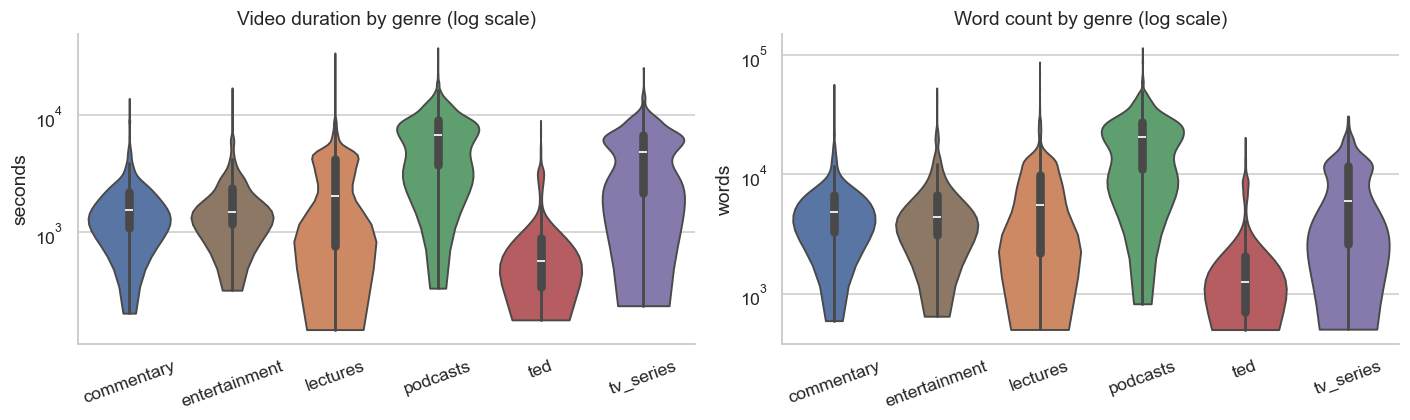


Duration (seconds) by genre:
                count         mean     50%          std
genre                                                  
commentary      900.0  1854.352222  1543.0  1370.390885
entertainment   820.0  1972.854878  1500.0  1620.590689
lectures       1200.0  2602.195000  2054.0  2429.759987
podcasts        900.0  6981.776667  6770.0  3983.830347
ted             700.0   895.207143   561.5  1031.019619
tv_series       480.0  4726.354167  4827.0  3248.870879


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, ylabel in [
    (axes[0], "duration_sec", "seconds"),
    (axes[1], "word_count",   "words"),
]:
    sns.violinplot(
        data=df, x="genre", y=col, order=GENRE_ORDER,
        palette=GENRE_PALETTE, inner="box", cut=0, ax=ax,
    )
    ax.set_yscale("log")
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=20)

axes[0].set_title("Video duration by genre (log scale)")
axes[1].set_title("Word count by genre (log scale)")
plt.tight_layout()
plt.show()

print("\nDuration (seconds) by genre:")
print(df.groupby("genre")["duration_sec"].describe()[["count", "mean", "50%", "std"]])


C:\Users\asus\AppData\Local\Temp\ipykernel_27672\2642593078.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


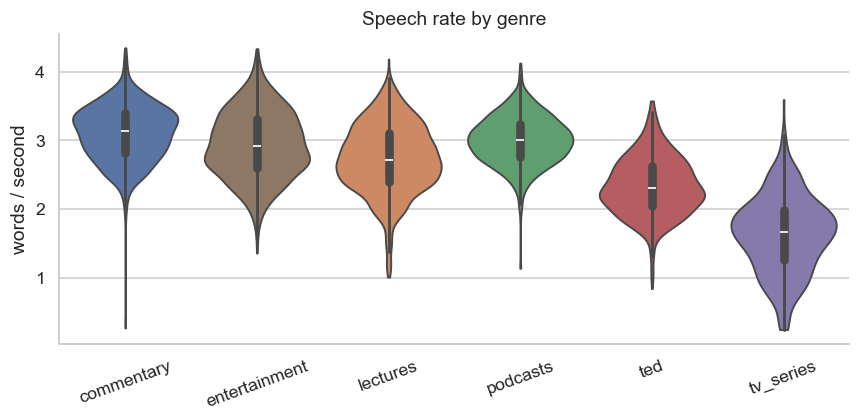

Speech rate (words/second) by genre:
                   mean       50%       std
genre                                      
commentary     3.099671  3.128908  0.413264
entertainment  2.935857  2.914434  0.485760
lectures       2.734886  2.715509  0.499720
podcasts       3.000408  3.000419  0.351668
ted            2.334476  2.302793  0.420404
tv_series      1.635168  1.668678  0.558060


In [8]:
df["speech_rate_wps"] = df["word_count"] / df["duration_sec"]

fig, ax = plt.subplots(figsize=(8, 4))
sns.violinplot(
    data=df, x="genre", y="speech_rate_wps", order=GENRE_ORDER,
    palette=GENRE_PALETTE, inner="box", cut=0, ax=ax,
)
ax.set_title("Speech rate by genre")
ax.set_ylabel("words / second")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

print("Speech rate (words/second) by genre:")
print(df.groupby("genre")["speech_rate_wps"].describe()[["mean", "50%", "std"]])


**H4 angle.** Speech rate is a transcript-only proxy for how much off-transcript content (silence, whiteboard work, slide reading) a video has. A lecture at 1.5 wps is doing visual work that the transcript model cannot see; a podcast at 2.8 wps is mostly verbal. Worth flagging in the H4 discussion.

## 4. Lexical features — H3 setup

Per-genre features that double as inputs to the weak labeling functions in Step 9.

In [9]:
FILLERS = {
    "um", "uh", "uhh", "ah", "er", "hmm",
    "like", "basically", "literally", "actually",
    "so", "okay", "right",
}
MULTIWORD_FILLERS = ["you know", "i mean", "sort of", "kind of", "or whatever"]


def transcript_text(transcript: list) -> str:
    return " ".join(e["text"] for e in transcript).lower()


def tokenize(transcript: list) -> list:
    return transcript_text(transcript).split()


def filler_density(transcript: list) -> float:
    """Unigram + multi-word filler tokens / total tokens."""
    text = transcript_text(transcript)
    words = text.split()
    if not words:
        return 0.0
    unigram_hits = sum(1 for w in words if w in FILLERS)
    multi_hits = sum(text.count(p) * len(p.split()) for p in MULTIWORD_FILLERS)
    return (unigram_hits + multi_hits) / len(words)


def ttr(transcript: list) -> float:
    """Type-token ratio — lexical diversity proxy."""
    words = tokenize(transcript)
    return len(set(words)) / len(words) if words else 0.0


df["filler_density"] = df["transcript"].apply(filler_density)
df["ttr"] = df["transcript"].apply(ttr)

print("Filler density by genre:")
print(df.groupby("genre")["filler_density"].describe()[["mean", "50%", "std"]])
print("\nType-token ratio by genre:")
print(df.groupby("genre")["ttr"].describe()[["mean", "50%", "std"]])

Filler density by genre:
                   mean       50%       std
genre                                      
commentary     0.032625  0.028179  0.016594
entertainment  0.037009  0.034303  0.015622
lectures       0.033172  0.028606  0.020523
podcasts       0.054870  0.048557  0.028261
ted            0.018646  0.014143  0.016730
tv_series      0.016832  0.014620  0.010633

Type-token ratio by genre:
                   mean       50%       std
genre                                      
commentary     0.287035  0.292866  0.066399
entertainment  0.270347  0.275516  0.056084
lectures       0.241213  0.218144  0.099358
podcasts       0.161437  0.155176  0.047264
ted            0.415181  0.421254  0.126450
tv_series      0.271125  0.247043  0.099409


C:\Users\asus\AppData\Local\Temp\ipykernel_27672\2105141993.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\asus\AppData\Local\Temp\ipykernel_27672\2105141993.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


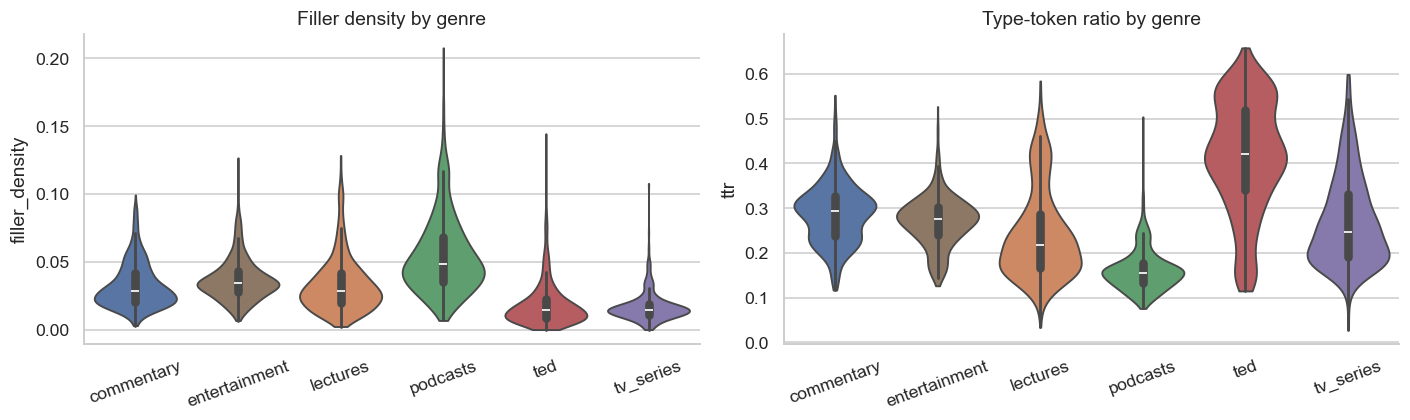

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, title in [
    (axes[0], "filler_density", "Filler density by genre"),
    (axes[1], "ttr",            "Type-token ratio by genre"),
]:
    sns.violinplot(
        data=df, x="genre", y=col, order=GENRE_ORDER,
        palette=GENRE_PALETTE, inner="box", cut=0, ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


## 5. Repetition proxies — H2 / H4 setup

Trigram repetition is a cheap surface-level redundancy proxy. **Caveat for the report:** trigram repetition does not distinguish *useful* repetition (pedagogical recap, summary) from *redundant* repetition (filler). That distinction is the model's job, not the proxy's. We use it here only to characterize the corpus.

C:\Users\asus\AppData\Local\Temp\ipykernel_27672\3562276583.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


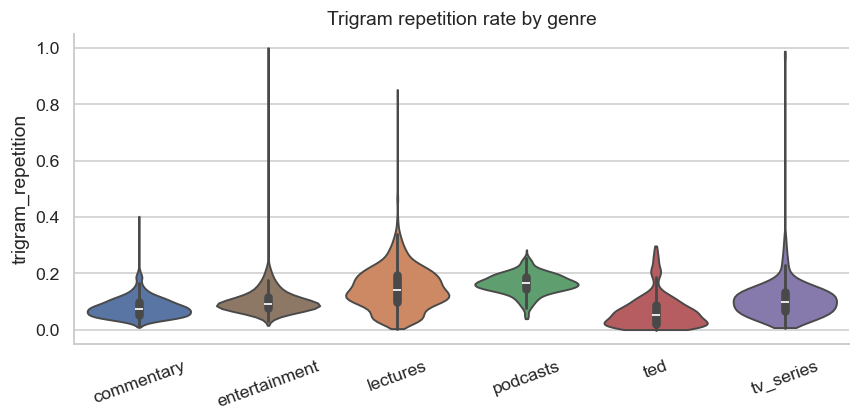

Trigram repetition by genre:
                   mean       50%       std
genre                                      
commentary     0.079520  0.073763  0.036645
entertainment  0.104340  0.091714  0.064430
lectures       0.146702  0.139674  0.075176
podcasts       0.162888  0.163671  0.036957
ted            0.064571  0.051447  0.057949
tv_series      0.106475  0.099197  0.077048


In [11]:
def trigram_repetition(transcript: list, n: int = 3) -> float:
    """Fraction of n-grams that occur more than once in the document."""
    words = tokenize(transcript)
    if len(words) < n:
        return 0.0
    ngrams = [tuple(words[i:i + n]) for i in range(len(words) - n + 1)]
    counts = Counter(ngrams)
    return sum(c for c in counts.values() if c > 1) / len(ngrams)


df["trigram_repetition"] = df["transcript"].apply(trigram_repetition)

fig, ax = plt.subplots(figsize=(8, 4))
sns.violinplot(
    data=df, x="genre", y="trigram_repetition", order=GENRE_ORDER,
    palette=GENRE_PALETTE, inner="box", cut=0, ax=ax,
)
ax.set_title("Trigram repetition rate by genre")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

print("Trigram repetition by genre:")
print(df.groupby("genre")["trigram_repetition"].describe()[["mean", "50%", "std"]])


## 6. Visual / pedagogical reference markers — H4 setup

Phrases like *"as you can see,"* *"on this slide,"* or *"look at this graph"* signal content whose meaning lives off-transcript. If a genre is heavy in these markers, a transcript-only model is structurally limited there — evidence for H4.

Visual reference markers per 1000 words:
                   mean       50%       std
genre                                      
commentary     0.579657  0.449608  0.553413
entertainment  1.280350  0.992926  1.150894
lectures       1.432738  1.058177  1.689132
podcasts       0.605140  0.530029  0.398273
ted            0.452229  0.000000  0.740999
tv_series      0.749093  0.623632  0.711429

Pedagogical markers per 1000 words:
                   mean       50%       std
genre                                      
commentary     0.249013  0.152520  0.331183
entertainment  0.062737  0.000000  0.185301
lectures       0.849472  0.557362  0.990901
podcasts       0.502112  0.355978  0.511592
ted            0.491107  0.000000  0.975928
tv_series      0.055620  0.000000  0.285487


C:\Users\asus\AppData\Local\Temp\ipykernel_27672\687160236.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\asus\AppData\Local\Temp\ipykernel_27672\687160236.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


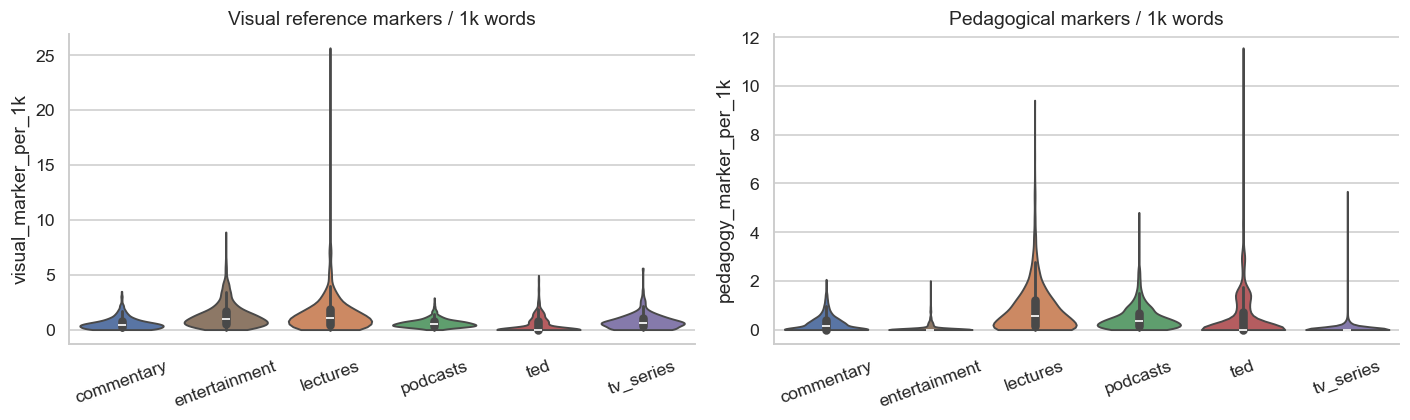

In [12]:
VISUAL_MARKERS = [
    "as you can see", "as you see", "look at", "on this slide",
    "on the screen", "this graph", "this chart", "this diagram",
    "this picture", "this image", "over here", "right here",
    "on the board", "on the left", "on the right",
]
PEDAGOGICAL_MARKERS = [
    "in other words", "to summarize", "to recap", "let me explain",
    "the key point", "the main idea", "for example", "for instance",
    "in conclusion", "the takeaway",
]


def marker_density(transcript: list, markers: list) -> float:
    text = transcript_text(transcript)
    n_words = len(text.split())
    if n_words == 0:
        return 0.0
    hits = sum(text.count(m) for m in markers)
    return hits / (n_words / 1000)  # hits per 1000 words


df["visual_marker_per_1k"]   = df["transcript"].apply(lambda t: marker_density(t, VISUAL_MARKERS))
df["pedagogy_marker_per_1k"] = df["transcript"].apply(lambda t: marker_density(t, PEDAGOGICAL_MARKERS))

print("Visual reference markers per 1000 words:")
print(df.groupby("genre")["visual_marker_per_1k"].describe()[["mean", "50%", "std"]])
print("\nPedagogical markers per 1000 words:")
print(df.groupby("genre")["pedagogy_marker_per_1k"].describe()[["mean", "50%", "std"]])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, title in [
    (axes[0], "visual_marker_per_1k",   "Visual reference markers / 1k words"),
    (axes[1], "pedagogy_marker_per_1k", "Pedagogical markers / 1k words"),
]:
    sns.violinplot(
        data=df, x="genre", y=col, order=GENRE_ORDER,
        palette=GENRE_PALETTE, inner="box", cut=0, ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


## 7. Length × redundancy — H1 in raw form

We can't measure removability without the model, but **trigram repetition** and **filler density** are defensible redundancy proxies. If H1 has any chance of being true, we should already see a positive duration-vs-redundancy correlation here. A negative or null correlation is informative — it would weaken the prior on H1.

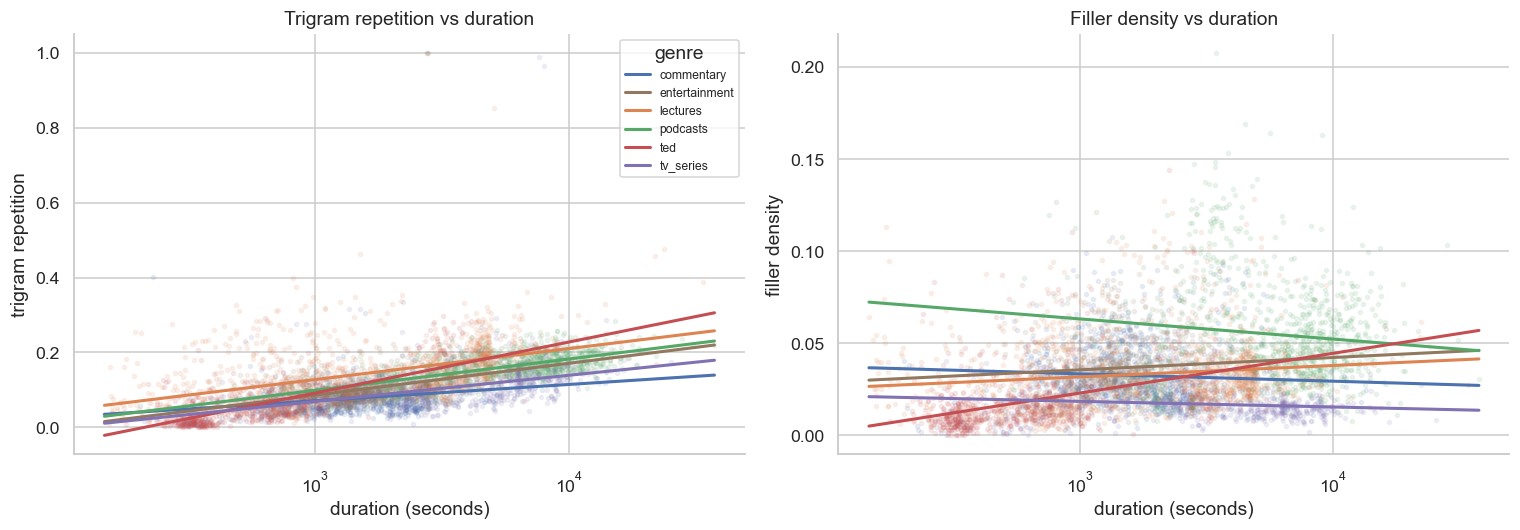


Spearman ρ(duration, trigram_repetition) per genre:
  commentary                 ρ = +0.270  (n=900)
  entertainment              ρ = +0.415  (n=820)
  lectures                   ρ = +0.534  (n=1200)
  podcasts                   ρ = +0.573  (n=900)
  ted                        ρ = +0.688  (n=700)
  tv_series                  ρ = +0.616  (n=480)

Spearman ρ(duration, filler_density) per genre:
  commentary                 ρ = -0.164  (n=900)
  entertainment              ρ = +0.151  (n=820)
  lectures                   ρ = +0.222  (n=1200)
  podcasts                   ρ = -0.076  (n=900)
  ted                        ρ = +0.475  (n=700)
  tv_series                  ρ = -0.083  (n=480)


In [13]:
# §7 — scatter with per-genre regression lines fit on log(duration)
# Low alpha + rasterized handles large N without overplotting.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for g in GENRE_ORDER:
    grp = df[df["genre"] == g].dropna(
        subset=["duration_sec", "trigram_repetition", "filler_density"]
    )
    c = GENRE_PALETTE[g]
    log_dur = np.log10(grp["duration_sec"].clip(lower=1))

    for ax, y_col in zip(axes, ["trigram_repetition", "filler_density"]):
        ax.scatter(grp["duration_sec"], grp[y_col],
                   color=c, alpha=0.10, s=7, rasterized=True, label="_nolegend_")
        # regression line on log(duration)
        coef = np.polyfit(log_dur, grp[y_col], 1)
        x_range = np.logspace(
            np.log10(df["duration_sec"].min()),
            np.log10(df["duration_sec"].max()),
            120,
        )
        ax.plot(x_range, np.polyval(coef, np.log10(x_range)),
                color=c, linewidth=2, label=g)

for ax, title, y_col in zip(
    axes,
    ["Trigram repetition vs duration", "Filler density vs duration"],
    ["trigram_repetition", "filler_density"],
):
    ax.set_xscale("log")
    ax.set_title(title)
    ax.set_xlabel("duration (seconds)")
    ax.set_ylabel(y_col.replace("_", " "))

axes[0].legend(title="genre", fontsize=8, markerscale=3)
plt.tight_layout()
plt.show()

print("\nSpearman ρ(duration, trigram_repetition) per genre:")
for g, sub in df.groupby("genre"):
    if len(sub) > 5:
        rho = sub[["duration_sec", "trigram_repetition"]].corr(method="spearman").iloc[0, 1]
        print(f"  {g:25s}  ρ = {rho:+.3f}  (n={len(sub)})")

print("\nSpearman ρ(duration, filler_density) per genre:")
for g, sub in df.groupby("genre"):
    if len(sub) > 5:
        rho = sub[["duration_sec", "filler_density"]].corr(method="spearman").iloc[0, 1]
        print(f"  {g:25s}  ρ = {rho:+.3f}  (n={len(sub)})")


## 8. Feature correlations

Quick sanity check: are these proxies measuring the same thing or capturing different facets? Strongly correlated features mean we can drop one when picking labeling functions; weakly correlated features mean each is contributing independent signal.

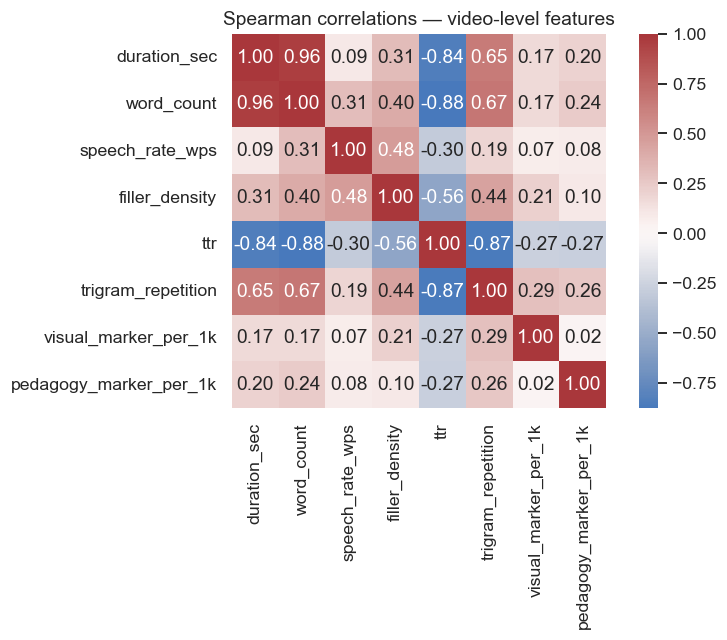

In [14]:
feature_cols = [
    "duration_sec", "word_count", "speech_rate_wps",
    "filler_density", "ttr", "trigram_repetition",
    "visual_marker_per_1k", "pedagogy_marker_per_1k",
]
corr = df[feature_cols].corr(method="spearman")

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, square=True)
plt.title("Spearman correlations — video-level features")
plt.tight_layout()
plt.show()

## 9. Save summary frame

Drop the heavy `transcript` column before saving — segment-level data lives in `data/processed/segments_*.jsonl` (created by `src/segment.py` later). The summary frame is what later hypothesis tests load.

In [15]:
summary = df.drop(columns=["transcript"])
out = PROCESSED_DIR / "corpus_summary.csv"
summary.to_csv(out, index=False)
print(f"Saved {len(summary):,} rows × {len(summary.columns)} columns to {out}")
summary.head()

Saved 5,000 rows × 15 columns to ..\data\processed\corpus_summary.csv


,video_id,genre,channel,title,duration_sec,length_bucket,caption_type,word_count,n_segments,speech_rate_wps,filler_density,ttr,trigram_repetition,visual_marker_per_1k,pedagogy_marker_per_1k
0,--CWTjd8rkY,commentary,Kurtis Conner,I Found a Super Weird Instructional Video from...,1582.0,long,auto,5314,771,3.359039,0.057396,0.226383,0.093185,0.188182,0.376364
1,--SXFB7m6mk,commentary,Folding Ideas,An American Tail: Fievel Goes to Video Game Hell,1326.0,long,manual,3690,327,2.782805,0.014092,0.391057,0.057755,0.000000,0.000000
2,-4lc3CG9_gg,commentary,Jarvis Johnson,Wasting Food For Clout,1663.0,long,manual,5203,758,3.128683,0.032481,0.264847,0.119208,0.576590,0.000000
3,-75m4h4I-m8,commentary,Nicole Rafiee,chronically online girl explains Stranger Thin...,2616.0,long,auto,9500,1347,3.631498,0.017579,0.247579,0.080017,0.421053,0.000000
4,-EzLk6BrzxQ,commentary,FunkyFrogBait,Let's Talk About BOOKTOK,2303.0,long,auto,6508,925,2.825879,0.026583,0.284112,0.056409,0.153657,0.153657


## 10. Things to revisit on the full corpus

When this notebook runs on the full 5000 documents, look out for:

- **Genre confound on length.** If lectures are systematically longer than TED talks, H1 (length effect) and H3 (genre effect) become entangled. Mitigation: stratify reporting by length bucket within each genre.
- **Caption-type confound.** If one genre is mostly auto-captioned, its filler density and trigram repetition can be inflated by ASR artifacts, not real verbal redundancy. Note in limitations and consider running the model separately on the manual-only subset as a robustness check.
- **Speech-rate outliers.** Videos under ~1.5 wps or over ~4 wps often indicate broken captions or unusual content (timelapses, supercuts). Spot-check 5 from each tail and decide whether to drop.
- **Marker densities.** If lectures dominate the visual-marker count by a wide margin, lectures are the genre where H4 (transcript-only model struggles) should bite hardest — this is the cell to cite when discussing H4 in the report.
- **Reproducibility.** The summary frame contains `video_id` and `title` so any later finding can be traced back to source.

## 11. Weak label analysis

Loads `data/processed/weak_labels.jsonl` (generated by `src/weak_labels.py`) and answers four questions:
1. What is the p_remove distribution per genre?
2. Which LFs fire most per genre — does the signal source differ?
3. Do weak labels correlate with the corpus proxies (filler density, trigram repetition)?
4. What do high/low p_remove segments actually look like?

**Run `python src/weak_labels.py` before this section.**

In [17]:
WEAK_LABELS_PATH = PROCESSED_DIR / "weak_labels.jsonl"

if not WEAK_LABELS_PATH.exists():
    print("⚠  weak_labels.jsonl not found. Run: python src/weak_labels.py")
else:
    wl = pd.read_json(WEAK_LABELS_PATH, lines=True)
    print(f"Loaded {len(wl):,} segment labels across {wl['video_id'].nunique()} videos")
    print(f"\np_remove distribution:")
    print(f"  mean={wl['p_remove'].mean():.3f}  std={wl['p_remove'].std():.3f}")
    print(f"  p > 0.70  (probably remove): {(wl['p_remove'] > 0.70).sum():,}  ({100*(wl['p_remove'] > 0.70).mean():.1f}%)")
    print(f"  0.30–0.70 (uncertain):        {((wl['p_remove'] >= 0.30) & (wl['p_remove'] <= 0.70)).sum():,}  ({100*((wl['p_remove'] >= 0.30) & (wl['p_remove'] <= 0.70)).mean():.1f}%)")
    print(f"  p < 0.30  (probably keep):   {(wl['p_remove'] < 0.30).sum():,}  ({100*(wl['p_remove'] < 0.30).mean():.1f}%)")
    wl.head(3)

Loaded 4,987 segment labels across 79 videos

p_remove distribution:
  mean=0.487  std=0.406
  p > 0.70  (probably remove): 1,911  (38.3%)
  0.30–0.70 (uncertain):        528  (10.6%)
  p < 0.30  (probably keep):   2,548  (51.1%)


C:\Users\asus\AppData\Local\Temp\ipykernel_27672\4088993846.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


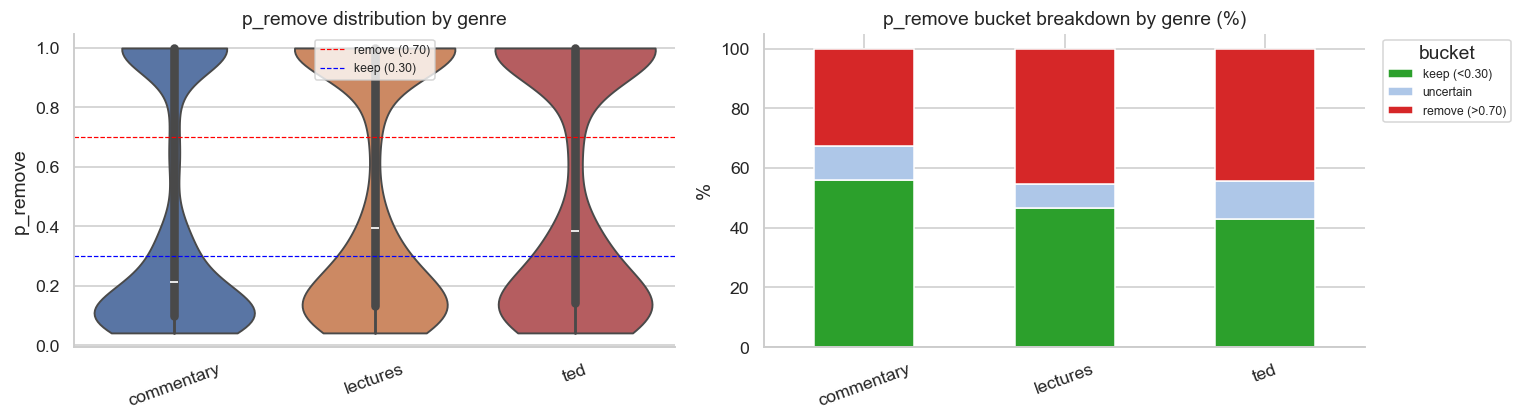


Mean p_remove by genre:
             count      mean     50%       std
genre                                         
commentary  2692.0  0.435614  0.2138  0.398157
lectures    1470.0  0.548543  0.3954  0.406761
ted          825.0  0.542496  0.3856  0.406031


In [18]:
# 11a. p_remove distribution by genre
if WEAK_LABELS_PATH.exists():
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # violin — only plot genres that are actually present in the weak-label data
    present = [g for g in GENRE_ORDER if g in wl["genre"].unique()]
    sns.violinplot(
        data=wl, x="genre", y="p_remove", order=present,
        palette=GENRE_PALETTE, cut=0, inner="box", ax=axes[0],
    )
    axes[0].axhline(0.70, color="red",  linestyle="--", linewidth=0.8, label="remove (0.70)")
    axes[0].axhline(0.30, color="blue", linestyle="--", linewidth=0.8, label="keep (0.30)")
    axes[0].set_title("p_remove distribution by genre")
    axes[0].set_ylabel("p_remove")
    axes[0].set_xlabel("")
    axes[0].tick_params(axis="x", rotation=20)
    axes[0].legend(fontsize=8)

    bucket_counts = (
        wl.assign(bucket=pd.cut(
            wl["p_remove"],
            bins=[-0.001, 0.30, 0.70, 1.001],
            labels=["keep (<0.30)", "uncertain", "remove (>0.70)"],
        ))
        .groupby(["genre", "bucket"], observed=True)
        .size()
        .unstack(fill_value=0)
    )
    bucket_pct = bucket_counts.div(bucket_counts.sum(axis=1), axis=0) * 100
    bucket_pct.reindex([g for g in GENRE_ORDER if g in bucket_pct.index]).plot(
        kind="bar", stacked=True,
        color=["#2ca02c", "#aec7e8", "#d62728"],
        ax=axes[1],
    )
    axes[1].set_title("p_remove bucket breakdown by genre (%)")
    axes[1].set_ylabel("%")
    axes[1].set_xlabel("")
    axes[1].tick_params(axis="x", rotation=20)
    axes[1].legend(title="bucket", bbox_to_anchor=(1.02, 1), fontsize=8)

    plt.tight_layout()
    plt.show()

    print("\nMean p_remove by genre:")
    print(wl.groupby("genre")["p_remove"].describe()[["count", "mean", "50%", "std"]])


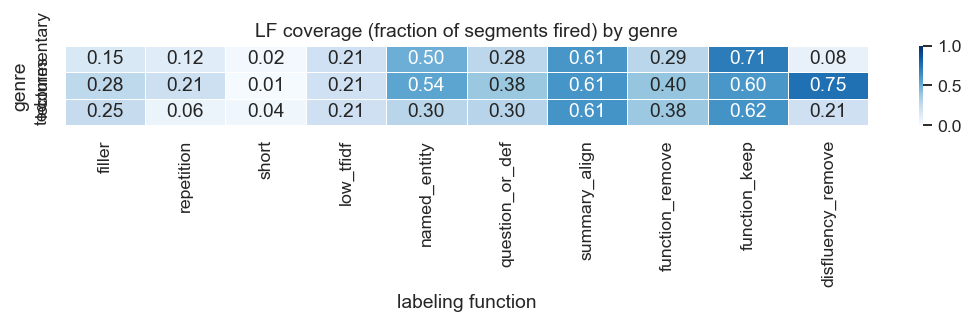


REMOVE rate per LF (of all segments, not just covered):
  LF_filler                  remove= 20.5%  keep=  0.0%
  LF_repetition              remove= 13.6%  keep=  0.0%
  LF_short                   remove=  2.3%  keep=  0.0%
  LF_low_tfidf               remove= 20.6%  keep=  0.0%
  LF_named_entity            remove=  0.0%  keep= 47.7%
  LF_question_or_def         remove=  0.0%  keep= 31.6%
  LF_summary_align           remove= 30.4%  keep= 30.4%
  LF_function_remove         remove= 33.6%  keep=  0.0%
  LF_function_keep           remove=  0.0%  keep= 66.4%
  LF_disfluency_remove       remove= 29.7%  keep=  0.0%


In [19]:

# 11b. LF coverage heatmap — which LFs fire per genre?
if WEAK_LABELS_PATH.exists():
    # Expand the votes dict column into separate columns
    lf_cols = pd.json_normalize(wl["votes"])
    wl_lf = pd.concat([wl[["video_id", "genre"]].reset_index(drop=True), lf_cols], axis=1)

    ABSTAIN = -1
    lf_names = lf_cols.columns.tolist()

    # Coverage = fraction of segments where LF did NOT abstain, per genre
    coverage = {}
    for genre, grp in wl_lf.groupby("genre"):
        coverage[genre] = {
            lf: float((grp[lf] != ABSTAIN).mean()) for lf in lf_names
        }
    cov_df = pd.DataFrame(coverage).T  # genres × LFs

    # Remove LF name prefix for cleaner labels
    cov_df.columns = [c.replace("LF_", "") for c in cov_df.columns]

    plt.figure(figsize=(10, 3))
    sns.heatmap(
        cov_df, annot=True, fmt=".2f", cmap="Blues",
        vmin=0, vmax=1, linewidths=0.5,
    )
    plt.title("LF coverage (fraction of segments fired) by genre")
    plt.ylabel("genre")
    plt.xlabel("labeling function")
    plt.tight_layout()
    plt.show()

    # Also show REMOVE vs KEEP rates per LF
    KEEP, REMOVE = 0, 1
    print("\nREMOVE rate per LF (of all segments, not just covered):")
    for lf in lf_names:
        n_remove = int((wl_lf[lf] == REMOVE).sum())
        n_keep   = int((wl_lf[lf] == KEEP).sum())
        total    = len(wl_lf)
        print(f"  {lf:25s}  remove={n_remove/total*100:5.1f}%  keep={n_keep/total*100:5.1f}%")


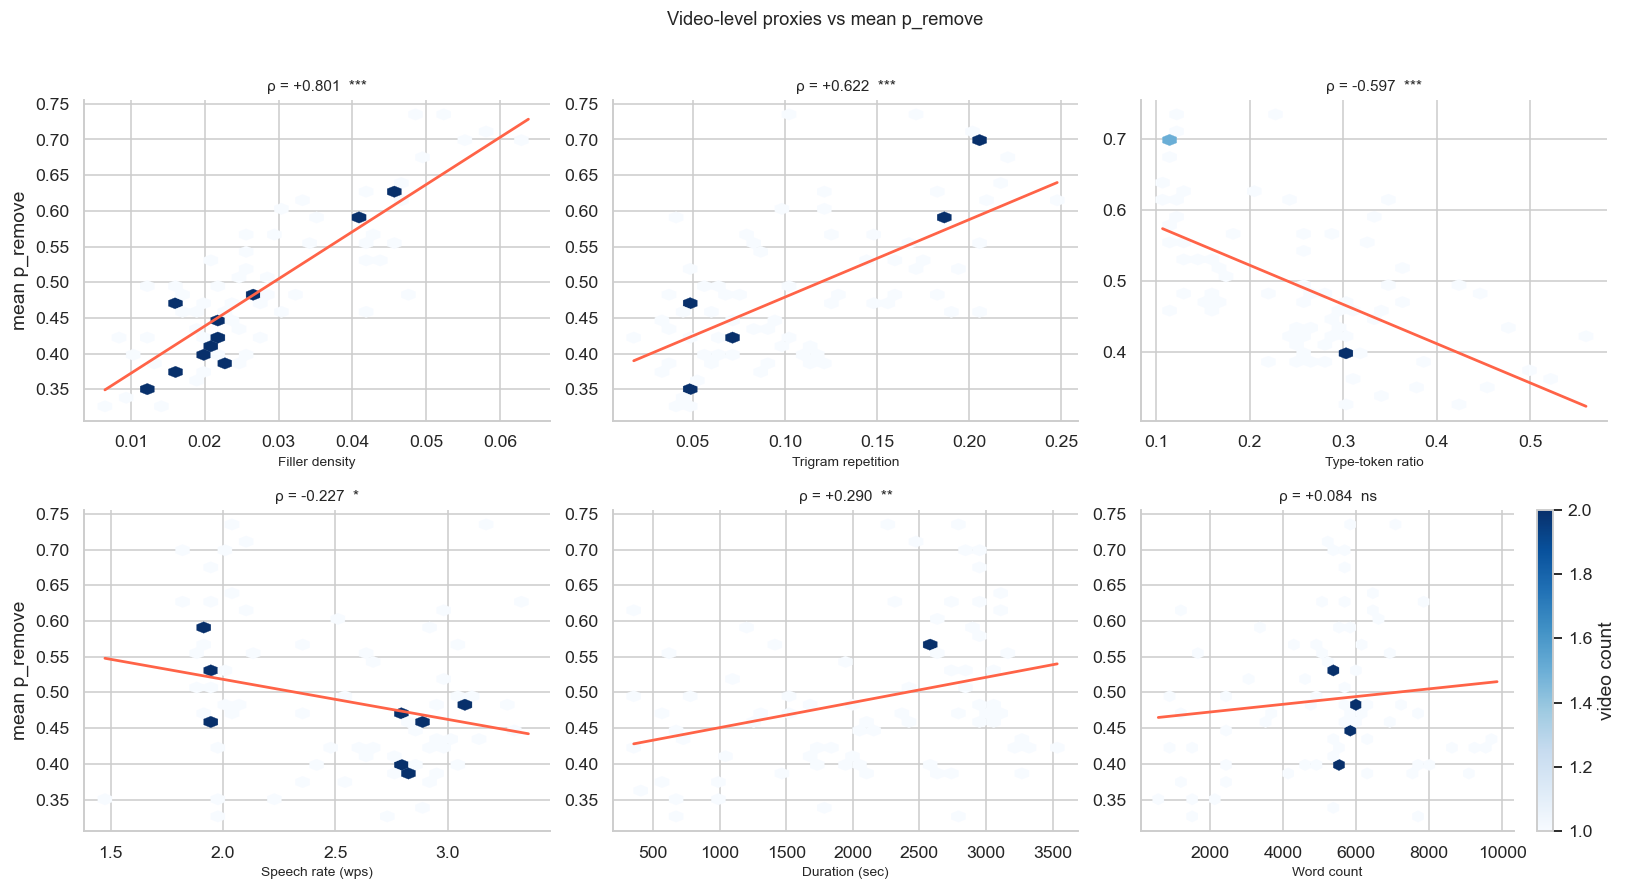


Spearman ρ(video feature, mean_p_remove):
  filler_density                  ρ = +0.801  ***  (n=79)
  trigram_repetition              ρ = +0.622  ***  (n=79)
  ttr                             ρ = -0.597  ***  (n=79)
  speech_rate_wps                 ρ = -0.227  *  (n=79)
  duration_sec                    ρ = +0.290  **  (n=79)
  word_count                      ρ = +0.084  ns  (n=79)


In [20]:
# 11c. Does p_remove correlate with corpus proxies?
# Hexbin density + regression line + Spearman ρ annotated on each panel.
if WEAK_LABELS_PATH.exists():
    vid_premove = wl.groupby("video_id")["p_remove"].mean().rename("mean_p_remove")
    summary_wl  = summary.join(vid_premove, on="video_id").dropna(subset=["mean_p_remove"])

    proxy_cols = [
        ("filler_density",       "Filler density"),
        ("trigram_repetition",   "Trigram repetition"),
        ("ttr",                  "Type-token ratio"),
        ("speech_rate_wps",      "Speech rate (wps)"),
        ("duration_sec",         "Duration (sec)"),
        ("word_count",           "Word count"),
    ]

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()

    for ax, (col, label) in zip(axes, proxy_cols):
        sub = summary_wl[[col, "mean_p_remove"]].dropna()
        rho, pval = stats.spearmanr(sub[col], sub["mean_p_remove"])
        sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "ns"

        hb = ax.hexbin(sub[col], sub["mean_p_remove"],
                       gridsize=30, cmap="Blues", mincnt=1, linewidths=0.2)

        # regression line
        coef = np.polyfit(sub[col], sub["mean_p_remove"], 1)
        x_range = np.linspace(sub[col].min(), sub[col].max(), 100)
        ax.plot(x_range, np.polyval(coef, x_range), color="tomato", linewidth=1.8)

        ax.set_xlabel(label, fontsize=9)
        ax.set_ylabel("mean p_remove" if ax in (axes[0], axes[3]) else "")
        ax.set_title(f"ρ = {rho:+.3f}  {sig}", fontsize=10)

    plt.colorbar(hb, ax=axes[-1], label="video count")
    plt.suptitle("Video-level proxies vs mean p_remove", y=1.01, fontsize=12)
    plt.tight_layout()
    plt.show()

    print("\nSpearman ρ(video feature, mean_p_remove):")
    for col, label in proxy_cols:
        sub = summary_wl[[col, "mean_p_remove"]].dropna()
        rho, pval = stats.spearmanr(sub[col], sub["mean_p_remove"])
        sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "ns"
        print(f"  {col:30s}  ρ = {rho:+.3f}  {sig}  (n={len(sub)})")


In [21]:

# 11d. Example segments: high vs low p_remove
# Load segments_topic.jsonl to recover the actual text for each (video_id, seg_idx).
if WEAK_LABELS_PATH.exists():
    SEGMENTS_PATH = PROCESSED_DIR / "segments_topic.jsonl"
    if not SEGMENTS_PATH.exists():
        print("⚠  segments_topic.jsonl not found — run src/segment.py first")
    else:
        segs = pd.read_json(SEGMENTS_PATH, lines=True)[["video_id", "seg_idx", "text"]]
        wl_text = wl.merge(segs, on=["video_id", "seg_idx"], how="left")

        for label, grp in [("HIGH p_remove  (>0.85, probably remove)", wl_text[wl_text["p_remove"] > 0.85]),
                            ("LOW  p_remove  (<0.15, probably keep)",   wl_text[wl_text["p_remove"] < 0.15])]:
            print(f"\n{'─'*60}")
            print(label)
            print(f"{'─'*60}")
            sample = grp.sample(min(5, len(grp)), random_state=42)
            for _, row in sample.iterrows():
                votes_str = "  ".join(
                    f"{k.replace('LF_', '')}={'R' if v==1 else 'K' if v==0 else '_'}"
                    for k, v in row["votes"].items()
                )
                text_preview = row["text"][:120].replace("\n", " ")
                print(f"\n  [{row['genre']}] p={row['p_remove']:.2f}  {votes_str}")
                print(f"  \"{text_preview}{'…' if len(row['text']) > 120 else ''}\"")



────────────────────────────────────────────────────────────
HIGH p_remove  (>0.85, probably remove)
────────────────────────────────────────────────────────────

  [lectures] p=0.96  filler=R  repetition=_  short=_  low_tfidf=_  named_entity=_  question_or_def=_  summary_align=R  function_remove=_  function_keep=K  disfluency_remove=R
  "Maybe I'll separate it into 3 A and 3B. Property 3A says that if I have that if I multiply one of the rows, say the firs…"

  [commentary] p=1.00  filler=_  repetition=_  short=_  low_tfidf=_  named_entity=K  question_or_def=_  summary_align=R  function_remove=R  function_keep=_  disfluency_remove=_
  "And he believed this caused him around  a hundred thousand dollars in damages, but the neighbor denied that it was his f…"

  [ted] p=1.00  filler=_  repetition=_  short=_  low_tfidf=_  named_entity=_  question_or_def=K  summary_align=K  function_remove=R  function_keep=_  disfluency_remove=R
  ">> It doesn't come up frequently. Uh >> why do you love t

## 12. Function label analysis (Head B)

Loads `data/processed/function_labels.jsonl` (generated by `src/function_labels.py`).

Questions:
1. What is the predicted function distribution across genres?
2. Which function classes drive the REMOVE/KEEP votes fed back into Head A?
3. Do function labels agree with p_remove where expected (discourse_filler ↔ high p_remove)?

**Run `python src/function_labels.py` before this section.**

Loaded 4,987 function labels across 79 videos


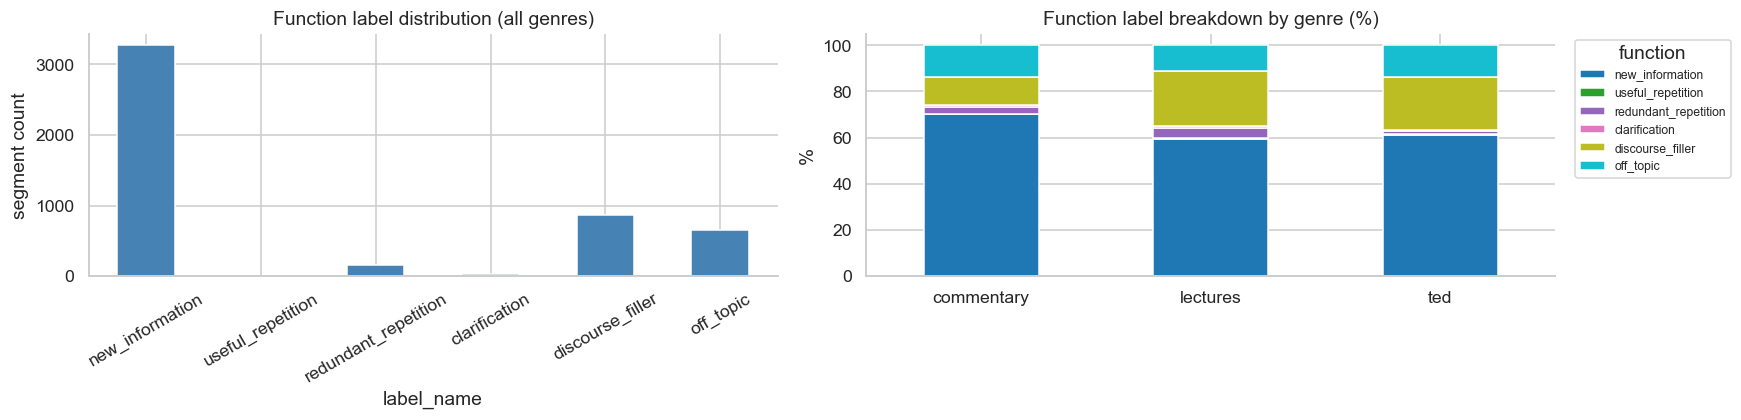


Overall counts:
label_name
new_information         3271
discourse_filler         867
off_topic                650
redundant_repetition     160
clarification             34
useful_repetition          5


In [22]:
FUNCTION_PATH = PROCESSED_DIR / "function_labels.jsonl"
FUNCTION_NAMES = ["new_information", "useful_repetition", "redundant_repetition",
                  "clarification", "discourse_filler", "off_topic"]
FUNCTION_REMOVE = {"redundant_repetition", "discourse_filler", "off_topic"}
FUNCTION_KEEP   = {"new_information", "useful_repetition", "clarification"}

if not FUNCTION_PATH.exists():
    print("⚠  function_labels.jsonl not found. Run: python src/function_labels.py")
else:
    fl = pd.read_json(FUNCTION_PATH, lines=True)
    print(f"Loaded {len(fl):,} function labels across {fl['video_id'].nunique()} videos")

    # 12a. Distribution
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    overall = fl["label_name"].value_counts().reindex(FUNCTION_NAMES, fill_value=0)
    overall.plot(kind="bar", ax=axes[0], color="steelblue")
    axes[0].set_title("Function label distribution (all genres)")
    axes[0].set_ylabel("segment count")
    axes[0].tick_params(axis="x", rotation=30)

    genre_fn = (
        fl.groupby(["genre", "label_name"])
          .size().unstack(fill_value=0)
          .reindex(columns=FUNCTION_NAMES, fill_value=0)
    )
    genre_fn_pct = genre_fn.div(genre_fn.sum(axis=1), axis=0) * 100
    genre_fn_pct.plot(kind="bar", stacked=True, colormap="tab10", ax=axes[1])
    axes[1].set_title("Function label breakdown by genre (%)")
    axes[1].set_ylabel("%")
    axes[1].set_xlabel("")
    axes[1].tick_params(axis="x", rotation=0)
    axes[1].legend(title="function", bbox_to_anchor=(1.02, 1), fontsize=8)
    plt.tight_layout()
    plt.show()

    print("\nOverall counts:")
    print(fl["label_name"].value_counts().to_string())


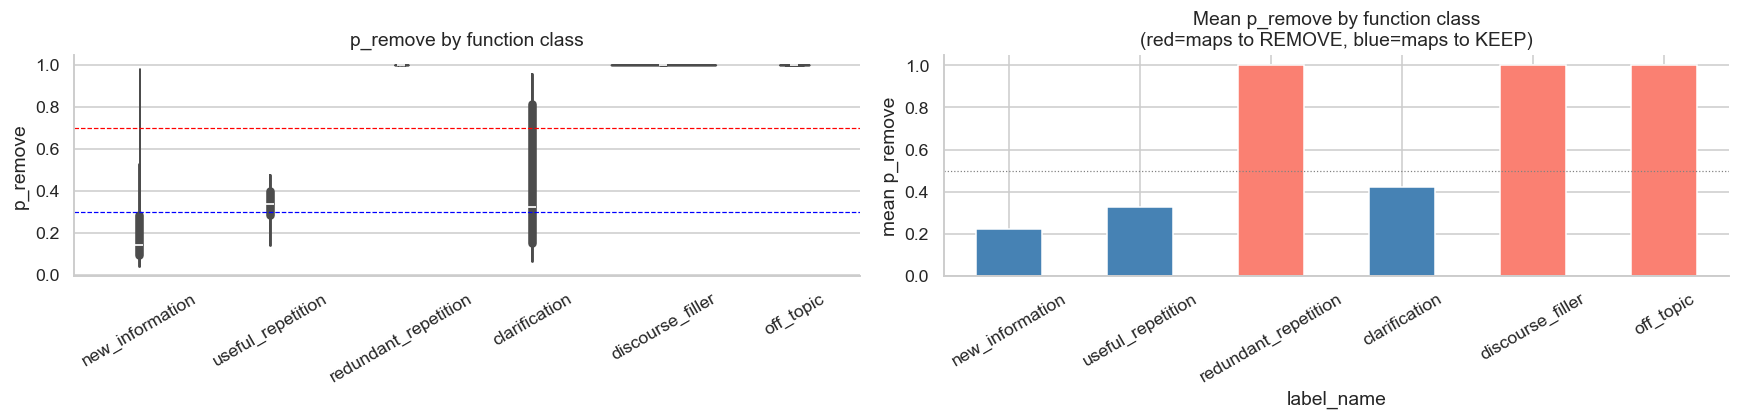


Mean p_remove by function class:
                       mean    std  count
label_name                               
new_information       0.224  0.214   3271
useful_repetition     0.328  0.127      5
redundant_repetition  1.000  0.000    160
clarification         0.421  0.321     34
discourse_filler      1.000  0.000    867
off_topic             1.000  0.000    650


In [23]:
# 12b. Do function labels agree with p_remove?
# removable classes should have higher p_remove; keepable classes should have lower.
if FUNCTION_PATH.exists() and WEAK_LABELS_PATH.exists():
    fl_wl = fl.merge(wl[["video_id", "seg_idx", "p_remove"]], on=["video_id", "seg_idx"], how="inner")

    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    # Violin of p_remove per function class
    order = FUNCTION_NAMES
    sns.violinplot(data=fl_wl, x="label_name", y="p_remove",
                   order=order, cut=0, inner="box", ax=axes[0])
    axes[0].axhline(0.70, color="red",  linestyle="--", linewidth=0.8)
    axes[0].axhline(0.30, color="blue", linestyle="--", linewidth=0.8)
    axes[0].set_title("p_remove by function class")
    axes[0].set_xlabel("")
    axes[0].tick_params(axis="x", rotation=30)

    # Mean p_remove per function class, coloured by REMOVE/KEEP mapping
    mean_p = fl_wl.groupby("label_name")["p_remove"].mean().reindex(FUNCTION_NAMES)
    colors = ["salmon" if n in FUNCTION_REMOVE else "steelblue" for n in FUNCTION_NAMES]
    mean_p.plot(kind="bar", color=colors, ax=axes[1])
    axes[1].set_title("Mean p_remove by function class\n(red=maps to REMOVE, blue=maps to KEEP)")
    axes[1].set_ylabel("mean p_remove")
    axes[1].tick_params(axis="x", rotation=30)
    axes[1].axhline(0.5, color="grey", linestyle=":", linewidth=0.8)

    plt.tight_layout()
    plt.show()

    print("\nMean p_remove by function class:")
    print(fl_wl.groupby("label_name")["p_remove"].agg(["mean", "std", "count"])
              .reindex(FUNCTION_NAMES).round(3).to_string())


## 13. Disfluency label analysis (Head C)

Loads `data/processed/disfluency_labels.jsonl` (generated by `src/disfluency_labels.py`).

Questions:
1. What fraction of segments contain disfluency, by genre?
2. Do disfluent segments have higher p_remove, as expected?
3. Does lecture auto-caption noise inflate disfluency rates?

**Run `python src/disfluency_labels.py` before this section.**

Loaded 4,987 disfluency labels across 79 videos


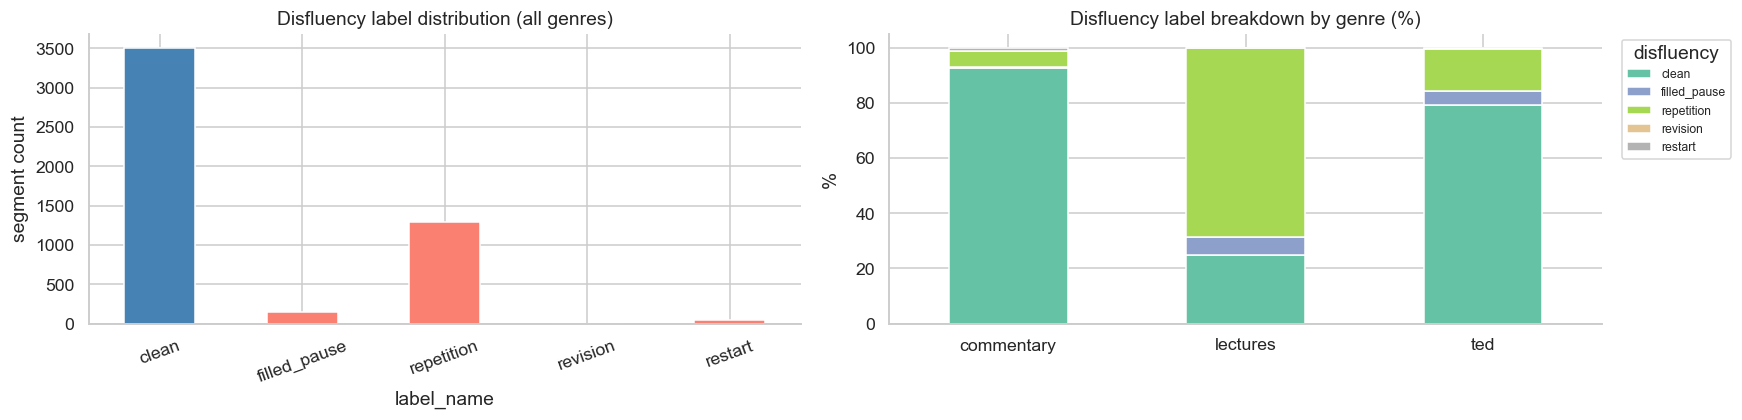

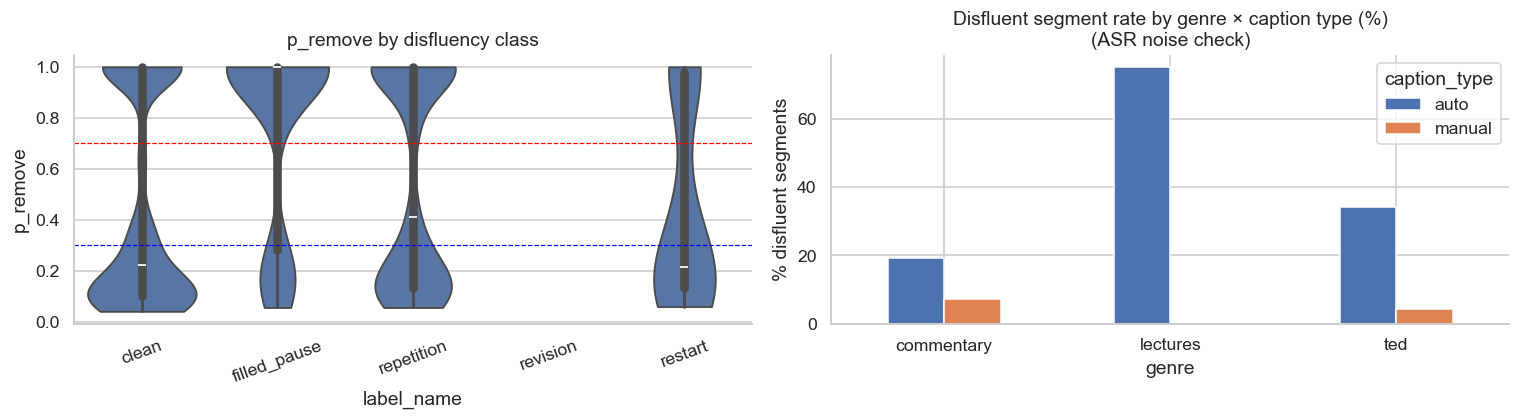


Mean p_remove by disfluency class:
               mean    std   count
label_name                        
clean         0.448  0.400  3508.0
filled_pause  0.770  0.364   151.0
repetition    0.559  0.404  1289.0
revision        NaN    NaN     NaN
restart       0.438  0.383    39.0


In [24]:
DISFLUENCY_PATH = PROCESSED_DIR / "disfluency_labels.jsonl"
DISFL_NAMES = ["clean", "filled_pause", "repetition", "revision", "restart"]
DISFL_REMOVE = {"filled_pause", "repetition", "revision", "restart"}

if not DISFLUENCY_PATH.exists():
    print("⚠  disfluency_labels.jsonl not found. Run: python src/disfluency_labels.py")
else:
    dl = pd.read_json(DISFLUENCY_PATH, lines=True)
    print(f"Loaded {len(dl):,} disfluency labels across {dl['video_id'].nunique()} videos")

    # 13a. Distribution by genre
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    overall_d = dl["label_name"].value_counts().reindex(DISFL_NAMES, fill_value=0)
    colors_d = ["steelblue" if n == "clean" else "salmon" for n in DISFL_NAMES]
    overall_d.plot(kind="bar", color=colors_d, ax=axes[0])
    axes[0].set_title("Disfluency label distribution (all genres)")
    axes[0].set_ylabel("segment count")
    axes[0].tick_params(axis="x", rotation=20)

    genre_dl = (
        dl.groupby(["genre", "label_name"])
          .size().unstack(fill_value=0)
          .reindex(columns=DISFL_NAMES, fill_value=0)
    )
    genre_dl_pct = genre_dl.div(genre_dl.sum(axis=1), axis=0) * 100
    genre_dl_pct.plot(kind="bar", stacked=True, colormap="Set2", ax=axes[1])
    axes[1].set_title("Disfluency label breakdown by genre (%)")
    axes[1].set_ylabel("%")
    axes[1].set_xlabel("")
    axes[1].tick_params(axis="x", rotation=0)
    axes[1].legend(title="disfluency", bbox_to_anchor=(1.02, 1), fontsize=8)
    plt.tight_layout()
    plt.show()

    # 13b. Disfluency vs p_remove
    if WEAK_LABELS_PATH.exists():
        dl_wl = dl.merge(wl[["video_id", "seg_idx", "p_remove"]], on=["video_id", "seg_idx"], how="inner")

        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        sns.violinplot(data=dl_wl, x="label_name", y="p_remove",
                       order=DISFL_NAMES, cut=0, inner="box", ax=axes[0])
        axes[0].axhline(0.70, color="red",  linestyle="--", linewidth=0.8)
        axes[0].axhline(0.30, color="blue", linestyle="--", linewidth=0.8)
        axes[0].set_title("p_remove by disfluency class")
        axes[0].tick_params(axis="x", rotation=20)

        # Caption type: disfluency rate in auto vs manual captions
        # dl already has genre; only pull caption_type from summary
        dl_cap = dl.merge(summary[["video_id", "caption_type"]],
                          on="video_id", how="left")
        dl_cap["is_disfluent"] = dl_cap["label_name"].isin(DISFL_REMOVE)
        cap_disfl = dl_cap.groupby(["genre", "caption_type"])["is_disfluent"].mean() * 100
        cap_disfl.unstack().plot(kind="bar", ax=axes[1])
        axes[1].set_title("Disfluent segment rate by genre × caption type (%)\n(ASR noise check)")
        axes[1].set_ylabel("% disfluent segments")
        axes[1].tick_params(axis="x", rotation=0)

        plt.tight_layout()
        plt.show()

        print("\nMean p_remove by disfluency class:")
        print(dl_wl.groupby("label_name")["p_remove"].agg(["mean", "std", "count"])
                  .reindex(DISFL_NAMES).round(3).to_string())


## 14. Gold annotation set

Selects up to 50 videos (commentary-heavy) and exports them in two formats:
- `data/gold/annotation_set.json` — master file used by eval scripts; `gold_label` fields are `null` until filled
- `data/gold/annotation_set.csv` — one big CSV for overview
- `data/gold/by_video/<video_id>.csv` — one CSV per video, easy to hand out to individual annotators

**Annotation task (for each segment):** decide whether it should be *removed* from the transcript without meaningful information loss.
- `1` = remove (filler, repetition, off-topic, pure disfluency)
- `0` = keep (new information, key claim, clarification)

The `guideline` column shows what the weak labeler suggested — use it as a hint, not a rule.


Columns available: ['video_id', 'genre', 'seg_idx', 'start', 'end', 'text', 'n_sentences', 'p_remove', 'title', 'channel', 'duration_sec']
⚠ No videos found for genre: entertainment
⚠ No videos found for genre: podcasts
⚠ No videos found for genre: tv_series

Selected 35 videos, 2,557 segments total

Breakdown by genre:
genre
commentary    25
lectures       5
ted            5

✓ Saved ..\data\gold\annotation_set.json
✓ Saved 35 per-video JSONs to ..\data\gold\by_video
✓ Saved ..\data\gold\annotation_set.csv
✓ Saved 35 per-video CSVs to ..\data\gold\by_video


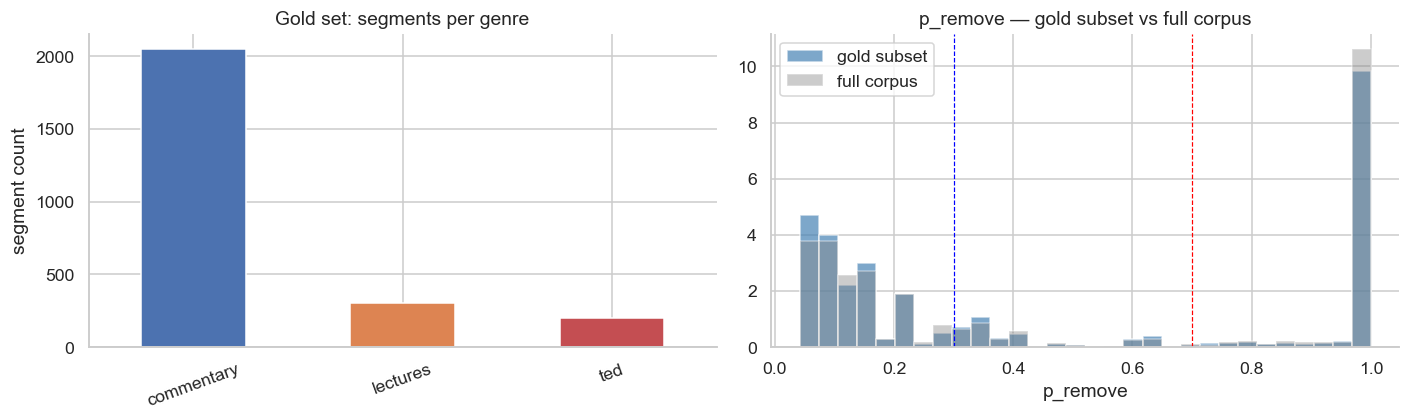


Gold set written to: ..\data\gold
  annotation_set.json  — master JSON for eval scripts
  annotation_set.csv   — full CSV for overview
  by_video/            — 35 JSON files + 35 CSV files


In [16]:
import csv, json, re, textwrap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

GOLD_DIR    = PROCESSED_DIR.parent / "gold"
BY_VID_DIR  = GOLD_DIR / "by_video"
GOLD_DIR.mkdir(parents=True, exist_ok=True)
BY_VID_DIR.mkdir(parents=True, exist_ok=True)

SEGMENTS_PATH    = PROCESSED_DIR / "segments_topic.jsonl"
WEAK_LABELS_PATH = PROCESSED_DIR / "weak_labels.jsonl"

if not SEGMENTS_PATH.exists():
    print("⚠ segments_topic.jsonl not found — run src/segment.py first")

elif not WEAK_LABELS_PATH.exists():
    print("⚠ weak_labels.jsonl not found — run src/weak_labels.py first")

else:
    # ── Load segments ───────────────────────────────────────────────────────
    segs_df = pd.read_json(SEGMENTS_PATH, lines=True)

    # ── Merge weak labels ───────────────────────────────────────────────────
    wl_df = pd.read_json(WEAK_LABELS_PATH, lines=True)[
        ["video_id", "seg_idx", "p_remove"]
    ]

    segs_df = segs_df.merge(
        wl_df,
        on=["video_id", "seg_idx"],
        how="left",
    )

    # ── Merge optional metadata from summary if available ───────────────────
    if "summary" in globals():
        extra_cols = [
            c for c in ["title", "channel", "duration_sec"]
            if c in summary.columns
        ]

        if extra_cols:
            segs_df = segs_df.merge(
                summary[["video_id"] + extra_cols],
                on="video_id",
                how="left",
            )

    print("Columns available:", segs_df.columns.tolist())

    # ── Sample 50 videos: commentary-heavy ─────────────────────────────────
    SAMPLE = {
        "commentary":    25,
        "entertainment":  5,
        "lectures":       5,
        "podcasts":       5,
        "ted":            5,
        "tv_series":      5,
    }

    rng = np.random.default_rng(seed=42)

    video_meta = segs_df.drop_duplicates("video_id").set_index("video_id")

    selected_ids = []

    for genre, n in SAMPLE.items():
        pool = video_meta[video_meta["genre"] == genre].index.tolist()

        if len(pool) == 0:
            print(f"⚠ No videos found for genre: {genre}")
            continue

        chosen = rng.choice(
            pool,
            size=min(n, len(pool)),
            replace=False,
        ).tolist()

        selected_ids.extend(chosen)

    gold_segs = segs_df[segs_df["video_id"].isin(selected_ids)].copy()
    gold_segs = gold_segs.sort_values(["video_id", "seg_idx"]).reset_index(drop=True)

    print(f"\nSelected {len(selected_ids)} videos, {len(gold_segs):,} segments total")

    print("\nBreakdown by genre:")
    print(
        gold_segs
        .drop_duplicates("video_id")
        .groupby("genre")
        .size()
        .to_string()
    )

    # ── Human-readable guideline ────────────────────────────────────────────
    def guideline(p_remove):
        if pd.isna(p_remove):
            return "no suggestion"

        conf = int(round(abs(p_remove - 0.5) * 200))
        label = "REMOVE" if p_remove >= 0.5 else "KEEP"

        return f"Suggested: {label}  (confidence: {conf}%)"

    gold_segs["guideline"] = gold_segs["p_remove"].apply(guideline)

    # ── Annotation schema ───────────────────────────────────────────────────
    ANNOTATION_SCHEMA = {
        "gold_removability": [
            "definitely_keep",
            "probably_keep",
            "unsure",
            "probably_remove",
            "definitely_remove",
        ],
        "gold_function": [
            "new_information",
            "useful_repetition",
            "redundant_repetition",
            "clarification",
            "discourse_filler",
            "off_topic",
        ],
        "gold_disfluency": [
            "clean",
            "filled_pause",
            "repetition",
            "revision",
            "restart",
        ],
    }

    REMOVABILITY_TO_SOFT_TARGET = {
        "definitely_keep": 0.00,
        "probably_keep": 0.25,
        "unsure": 0.50,
        "probably_remove": 0.75,
        "definitely_remove": 1.00,
    }

    FUNCTION_TO_BINARY_REMOVE = {
        "new_information": 0,
        "useful_repetition": 0,
        "clarification": 0,
        "redundant_repetition": 1,
        "discourse_filler": 1,
        "off_topic": 1,
    }

    def safe_filename(x):
        x = str(x)
        x = re.sub(r"[^A-Za-z0-9._-]+", "_", x)
        return x[:120] if x else "video"

    # ── Build master JSON ───────────────────────────────────────────────────
    annotation_set = []

    for vid_id, grp in gold_segs.groupby("video_id", sort=False):
        r0 = grp.iloc[0]

        video_obj = {
            "video_id": str(vid_id),
            "title": str(r0.get("title", "")),
            "channel": str(r0.get("channel", "")),
            "genre": str(r0.get("genre", "")),
            "duration_sec": float(r0.get("duration_sec", 0) or 0),

            "annotation_schema": ANNOTATION_SCHEMA,
            "removability_to_soft_target": REMOVABILITY_TO_SOFT_TARGET,
            "function_to_binary_remove": FUNCTION_TO_BINARY_REMOVE,

            "segments": [
                {
                    "seg_idx": int(r["seg_idx"]),
                    "text": str(r["text"]),

                    "weak_p_remove": (
                        round(float(r["p_remove"]), 4)
                        if not pd.isna(r["p_remove"])
                        else None
                    ),
                    "guideline": str(r["guideline"]),

                    # Fill these three manually.
                    "gold_removability": None,
                    "gold_function": None,
                    "gold_disfluency": None,

                    "notes": "",
                }
                for _, r in grp.iterrows()
            ],
        }

        annotation_set.append(video_obj)

    # ── Master JSON ─────────────────────────────────────────────────────────
    json_path = GOLD_DIR / "annotation_set.json"

    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(annotation_set, f, ensure_ascii=False, indent=2)

    print(f"\n✓ Saved {json_path}")

    # ── Per-video JSONs ─────────────────────────────────────────────────────
    for vid in annotation_set:
        vid_json_path = BY_VID_DIR / f"{safe_filename(vid['video_id'])}.json"

        with open(vid_json_path, "w", encoding="utf-8") as f:
            json.dump(vid, f, ensure_ascii=False, indent=2)

    print(f"✓ Saved {len(annotation_set)} per-video JSONs to {BY_VID_DIR}")

    # ── CSV instructions ────────────────────────────────────────────────────
    CSV_COLS = [
        "video_id",
        "title",
        "genre",
        "channel",
        "seg_idx",
        "text",
        "weak_p_remove",
        "guideline",
        "gold_removability",
        "gold_function",
        "gold_disfluency",
        "notes",
    ]

    INSTRUCTIONS = textwrap.dedent("""
        ANNOTATION INSTRUCTIONS
        =======================
        You are reading transcript segments from YouTube videos.

        For each segment, fill THREE label columns:

        1) gold_removability
           Choose one:
               definitely_keep
               probably_keep
               unsure
               probably_remove
               definitely_remove

        2) gold_function
           Choose one:
               new_information
               useful_repetition
               redundant_repetition
               clarification
               discourse_filler
               off_topic

        3) gold_disfluency
           Choose one:
               clean
               filled_pause
               repetition
               revision
               restart

        The "guideline" column is the automatic model suggestion.
        Treat it as a hint only. Human judgment is the gold label.

        Optional: add a short reason in the notes column.
        =======================
    """).strip()

    # ── Master CSV ──────────────────────────────────────────────────────────
    csv_path = GOLD_DIR / "annotation_set.csv"

    with open(csv_path, "w", newline="", encoding="utf-8") as f:
        f.write("# " + INSTRUCTIONS.replace("\n", "\n# ") + "\n#\n")

        writer = csv.DictWriter(f, fieldnames=CSV_COLS)
        writer.writeheader()

        for vid in annotation_set:
            for seg in vid["segments"]:
                writer.writerow({
                    "video_id": vid["video_id"],
                    "title": vid["title"],
                    "genre": vid["genre"],
                    "channel": vid["channel"],
                    "seg_idx": seg["seg_idx"],
                    "text": seg["text"],
                    "weak_p_remove": seg["weak_p_remove"],
                    "guideline": seg["guideline"],

                    # Fill these three manually.
                    "gold_removability": "",
                    "gold_function": "",
                    "gold_disfluency": "",

                    "notes": "",
                })

    print(f"✓ Saved {csv_path}")

    # ── Per-video CSVs ──────────────────────────────────────────────────────
    for vid in annotation_set:
        vid_csv_path = BY_VID_DIR / f"{safe_filename(vid['video_id'])}.csv"

        with open(vid_csv_path, "w", newline="", encoding="utf-8") as f:
            f.write("# " + INSTRUCTIONS.replace("\n", "\n# ") + "\n#\n")
            f.write(f"# Video  : {vid['title']}\n")
            f.write(f"# Channel: {vid['channel']}   |   Genre: {vid['genre']}\n#\n")

            writer = csv.DictWriter(f, fieldnames=CSV_COLS)
            writer.writeheader()

            for seg in vid["segments"]:
                writer.writerow({
                    "video_id": vid["video_id"],
                    "title": vid["title"],
                    "genre": vid["genre"],
                    "channel": vid["channel"],
                    "seg_idx": seg["seg_idx"],
                    "text": seg["text"],
                    "weak_p_remove": seg["weak_p_remove"],
                    "guideline": seg["guideline"],

                    # Fill these three manually.
                    "gold_removability": "",
                    "gold_function": "",
                    "gold_disfluency": "",

                    "notes": "",
                })

    print(f"✓ Saved {len(annotation_set)} per-video CSVs to {BY_VID_DIR}")

    # ── Summary plot ────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    if "GENRE_ORDER" in globals():
        genre_order = [g for g in GENRE_ORDER if g in gold_segs["genre"].values]
    else:
        genre_order = sorted(gold_segs["genre"].dropna().unique().tolist())

    seg_counts = (
        pd.DataFrame([
            {"genre": v["genre"], "n_segs": len(v["segments"])}
            for v in annotation_set
        ])
        .groupby("genre")["n_segs"]
        .sum()
        .reindex(genre_order)
    )

    if "GENRE_PALETTE" in globals():
        colors = [GENRE_PALETTE.get(g, None) for g in seg_counts.index]
    else:
        colors = None

    seg_counts.plot(
        kind="bar",
        color=colors,
        ax=axes[0],
    )

    axes[0].set_title("Gold set: segments per genre")
    axes[0].set_ylabel("segment count")
    axes[0].set_xlabel("")
    axes[0].tick_params(axis="x", rotation=20)

    gold_p = gold_segs["p_remove"].dropna()
    all_p = wl_df["p_remove"].dropna()

    axes[1].hist(
        gold_p,
        bins=30,
        color="steelblue",
        alpha=0.7,
        label="gold subset",
        density=True,
    )

    axes[1].hist(
        all_p,
        bins=30,
        color="grey",
        alpha=0.4,
        label="full corpus",
        density=True,
    )

    axes[1].axvline(0.7, color="red", linestyle="--", linewidth=0.8)
    axes[1].axvline(0.3, color="blue", linestyle="--", linewidth=0.8)
    axes[1].set_title("p_remove — gold subset vs full corpus")
    axes[1].set_xlabel("p_remove")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    print(f"\nGold set written to: {GOLD_DIR}")
    print("  annotation_set.json  — master JSON for eval scripts")
    print("  annotation_set.csv   — full CSV for overview")
    print(f"  by_video/            — {len(annotation_set)} JSON files + {len(annotation_set)} CSV files")